c:\Users\Hp\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


best parameters:  {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
Best CV score 0.9780219780219781

 Accuracy 0.9649122807017544

 confusion matrix: 
[[41  2]
 [ 2 69]]

 classification report: 
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



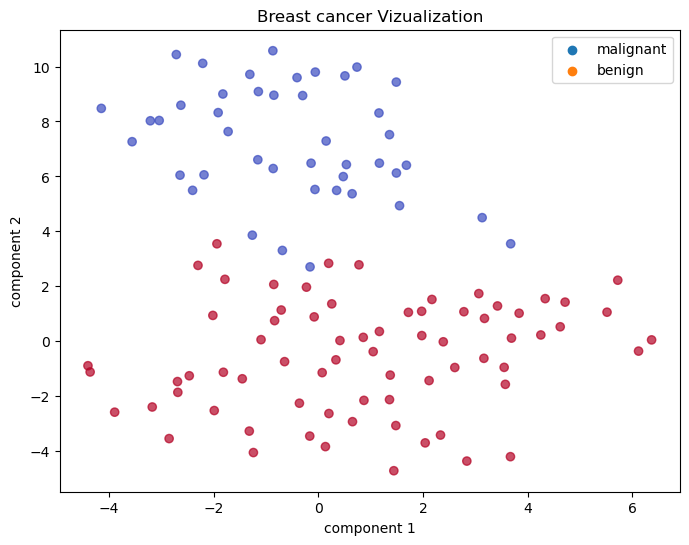

In [ ]:
# Load dataset
# 2. EDA (graphs)
# 3. Data cleaning
# 4. Feature scaling
# 5. Train/Test split
# 6. Model training
# 7. Evaluation (accuracy, etc.)
# 8. Visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.utils import Bunch
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = load_breast_cancer()

df = pd.DataFrame(data['data'], columns = data['feature_names'])
df['target'] = data.target
# print(df.head())

x = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2, random_state=42
)

#feature scaling
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

model = LogisticRegression()

parameters =[
    {
        'penalty':['l1'],
        'C':[0.1, 0.01, 0.5, 1, 10],
        'solver':['liblinear', 'saga'],
        'max_iter':[1000]
    },
    {
        'penalty':['l2'],
        'C':[0.1, 0.01, 0.5, 1, 10],
        'solver':['lbfgs','liblinear', 'saga'],
        'max_iter':[1000]
    }
]

grid = GridSearchCV(model, param_grid=parameters, cv=5, scoring='accuracy', n_jobs=-1)


grid.fit(X_train, y_train)

print("best parameters: ", grid.best_params_)
print("Best CV score", grid.best_score_)

y_pred = grid.predict(X_test)
print("\n Accuracy", accuracy_score(y_test, y_pred))
print("\n confusion matrix: ")
print(confusion_matrix(y_test, y_pred))
print("\n classification report: ")
print(classification_report(y_test, y_pred))


# plt.figure(figsize=(10,8))
# sns.heatmap(df.corr(), cmap='coolwarm')
# plt.title("Feature Correlation Heatmap")
# plt.show()


# train_acc = grid.score(X_train, y_train)
# test_acc = grid.score(X_test, y_test)

# print("Train Accuracy:", train_acc)
# print("Test Accuracy:", test_acc)

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c =y_test,
    cmap = 'coolwarm',
    alpha=0.7
)

plt.title("Breast cancer Vizualization")
plt.xlabel("component 1")
plt.ylabel("component 2")

for label in np.unique(y_test):
    plt.scatter([], [], label=data.target_names[label])

plt.legend()
plt.show()